# Logistic Regression Testing Process (CIFAR-10)

This notebook documents a complete, reproducible **logistic regression baseline**

In [2]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path
import json
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 178
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
else:
    DEVICE = torch.device("cpu")

ROOT = Path.cwd().parent.parent
TRAIN_DIR = ROOT / "data" / "cifar10" / "train"
TEST_DIR = ROOT / "data" / "cifar10" / "test"
GRAPH_DIR = ROOT / "outputs" / "graphs"
WEIGHTS_DIR = ROOT / "outputs" / "model_weights"
RESULTS_DIR = ROOT / "results"

GRAPH_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    print("GPU: Apple Metal (MPS)")
else:
    print("GPU: CPU only")
print(f"Train: {TRAIN_DIR}")
print(f"Test: {TEST_DIR}")

Device: cpu
GPU: CPU only
Train: /Users/anishsajja/Documents/GitHub/CS178-goop-squad-CIFAR10/data/cifar10/train
Test: /Users/anishsajja/Documents/GitHub/CS178-goop-squad-CIFAR10/data/cifar10/test


## Data Protocol

This notebook follows the CS178 protocol:

- keep the provided `test` directory untouched during model development,
- use only the `train` directory for training and validation,
- create a **75/25 split inside the training directory**,
- report final test performance only after selecting the best validation configuration.

Because logistic regression expects vector features, each image is converted into a **flattened feature vector**. Two feature modes are supported:
1. **raw**: normalized flattened pixels,
2. **pca**: normalized flattened pixels followed by PCA.


In [3]:
def make_eval_transform(input_size: int = 32) -> transforms.Compose:
    return transforms.Compose(
        [
            transforms.Resize((input_size, input_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
        ]
    )


def load_imagefolder_arrays(
    directory: Path, input_size: int = 32
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    transform = make_eval_transform(input_size=input_size)
    dataset = datasets.ImageFolder(str(directory), transform=transform)

    features, labels = [], []
    for image, label in dataset:
        features.append(image.numpy().reshape(-1).astype(np.float32))
        labels.append(label)

    X = np.stack(features)
    y = np.asarray(labels, dtype=np.int64)
    return X, y, dataset.classes


def make_splits(
    input_size: int = 32,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, list[str]]:
    X_train_full, y_train_full, classes = load_imagefolder_arrays(TRAIN_DIR, input_size=input_size)
    X_test, y_test, test_classes = load_imagefolder_arrays(TEST_DIR, input_size=input_size)

    assert classes == test_classes, "Train/test class names are inconsistent."

    train_idx, val_idx = train_test_split(
        np.arange(len(X_train_full)),
        test_size=0.25,
        random_state=SEED,
        stratify=y_train_full,
    )

    X_train = X_train_full[train_idx]
    y_train = y_train_full[train_idx]
    X_val = X_train_full[val_idx]
    y_val = y_train_full[val_idx]

    return X_train, y_train, X_val, y_val, X_test, y_test, classes


X_train, y_train, X_val, y_val, X_test, y_test, class_names = make_splits(input_size=32)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("Classes:", class_names)

Train shape: (37500, 3072)
Val shape: (12500, 3072)
Test shape: (10000, 3072)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Baseline Model Definition

We use **multinomial logistic regression** for the baseline. This is a linear classifier over flattened CIFAR-10 features.

The pipeline is:

- `StandardScaler` on feature vectors,
- optional `PCA`,
- `LogisticRegression(multi_class="multinomial")`.

In [4]:
@dataclass(frozen=True)
class RunConfig:
    model_label: str
    C: float = 1.0
    max_iter: int = 200
    feature_mode: str = "raw"   # "raw" or "pca"
    pca_dim: int = 256
    solver: str = "saga"


def create_pipeline(config: RunConfig) -> Pipeline:
    steps: list[tuple[str, object]] = [("scaler", StandardScaler())]

    if config.feature_mode == "pca":
        steps.append(
            ("pca", PCA(n_components=config.pca_dim, random_state=SEED))
        )

    steps.append(
        (
            "logreg",
            LogisticRegression(
                C=config.C,
                max_iter=config.max_iter,
                solver=config.solver,
                multi_class="multinomial",
                random_state=SEED,
                n_jobs=-1,
                verbose=0,
            ),
        )
    )

    return Pipeline(steps)

In [5]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, classes: list[str]) -> dict:
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(len(classes)), zero_division=0
    )

    per_class = {
        classes[i]: {
            "precision": float(precision[i]),
            "recall": float(recall[i]),
            "f1": float(f1[i]),
            "support": int(support[i]),
        }
        for i in range(len(classes))
    }

    return {
        "accuracy": float(accuracy),
        "macro_precision": float(np.mean(precision)),
        "macro_recall": float(np.mean(recall)),
        "macro_f1": float(np.mean(f1)),
        "per_class": per_class,
    }


def save_pickle(obj, path: Path) -> None:
    with open(path, "wb") as f:
        pickle.dump(obj, f)


def train_one_model(config: RunConfig) -> dict:
    pipeline = create_pipeline(config)
    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    val_pred = pipeline.predict(X_val)

    train_metrics = compute_metrics(y_train, train_pred, class_names)
    val_metrics = compute_metrics(y_val, val_pred, class_names)

    best_model_path = WEIGHTS_DIR / f"{config.model_label.lower()}_best.pkl"
    save_pickle({"config": asdict(config), "pipeline": pipeline, "classes": class_names}, best_model_path)

    result = {
        "config": asdict(config),
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "weights_path": str(best_model_path),
    }

    summary_path = RESULTS_DIR / f"{config.model_label.lower()}_summary.json"
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    return result


def evaluate_saved_model(weights_path: Path) -> dict:
    with open(weights_path, "rb") as f:
        payload = pickle.load(f)

    pipeline = payload["pipeline"]
    y_pred = pipeline.predict(X_test)
    metrics = compute_metrics(y_test, y_pred, class_names)
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))

    return {
        "config": payload["config"],
        "classes": payload["classes"],
        "y_pred": y_pred,
        "metrics": metrics,
        "confusion_matrix": cm,
    }

In [7]:
def plot_confusion(cm: np.ndarray, classes: list[str], title: str, stem: str) -> Path:
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    fig.tight_layout()

    out_path = GRAPH_DIR / f"{stem}_confusion_matrix.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    return out_path


def plot_model_comparison(rows: list[dict], stem: str = "logreg_model_comparison") -> Path:
    df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(df))
    width = 0.35
    ax.bar(x - width / 2, df["train_accuracy"], width, label="Train Accuracy")
    ax.bar(x + width / 2, df["val_accuracy"], width, label="Val Accuracy")

    ax.set_xticks(x)
    ax.set_xticklabels(df["model_label"], rotation=0)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Accuracy")
    ax.set_title("Logistic Regression Validation Comparison")
    ax.legend()
    fig.tight_layout()

    out_path = GRAPH_DIR / f"{stem}.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    return out_path

## Experiment 1: Raw Flattened Pixels

This experiment trains multinomial logistic regression directly on normalized flattened CIFAR-10 pixels.


In [8]:
config_raw = RunConfig(
    model_label="LogRegRaw",
    C=1.0,
    max_iter=200,
    feature_mode="raw",
    solver="saga",
)

result_raw = train_one_model(config_raw)
print(json.dumps(result_raw["train_metrics"], indent=2))
print(json.dumps(result_raw["val_metrics"], indent=2))

/Users/anishsajja/Documents/GitHub/CS178-goop-squad-CIFAR10/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/anishsajja/Documents/GitHub/CS178-goop-squad-CIFAR10/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{
  "accuracy": 0.5103733333333333,
  "macro_precision": 0.5076492768073486,
  "macro_recall": 0.5103733333333333,
  "macro_f1": 0.5083293045443067,
  "per_class": {
    "airplane": {
      "precision": 0.5394076305220884,
      "recall": 0.5730666666666666,
      "f1": 0.5557279544866822,
      "support": 3750
    },
    "automobile": {
      "precision": 0.5610755441741357,
      "recall": 0.5842666666666667,
      "f1": 0.5724363161332462,
      "support": 3750
    },
    "bird": {
      "precision": 0.4328899637243047,
      "recall": 0.3818666666666667,
      "f1": 0.4057806744120147,
      "support": 3750
    },
    "cat": {
      "precision": 0.4060213843556556,
      "recall": 0.3848,
      "f1": 0.3951259583789704,
      "support": 3750
    },
    "deer": {
      "precision": 0.4816833181955798,
      "recall": 0.4242666666666667,
      "f1": 0.45115553665107044,
      "support": 3750
    },
    "dog": {
      "precision": 0.4458154506437768,
      "recall": 0.4432,
      "f1"

### Findings: LogRegRaw

This is the simplest linear baseline in the notebook. It is useful for measuring how much performance can be achieved from raw flattened features without any learned hidden representation.


## Experiment 2: PCA-Reduced Logistic Regression

This experiment applies PCA before logistic regression. It can reduce dimensionality and training cost while sometimes improving generalization.


In [9]:
config_pca = RunConfig(
    model_label="LogRegPCA",
    C=1.0,
    max_iter=250,
    feature_mode="pca",
    pca_dim=256,
    solver="saga",
)

result_pca = train_one_model(config_pca)
print(json.dumps(result_pca["train_metrics"], indent=2))
print(json.dumps(result_pca["val_metrics"], indent=2))

/Users/anishsajja/Documents/GitHub/CS178-goop-squad-CIFAR10/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{
  "accuracy": 0.43290666666666666,
  "macro_precision": 0.4282333101787542,
  "macro_recall": 0.43290666666666666,
  "macro_f1": 0.429304994142358,
  "per_class": {
    "airplane": {
      "precision": 0.4722782258064516,
      "recall": 0.4997333333333333,
      "f1": 0.48561803576055973,
      "support": 3750
    },
    "automobile": {
      "precision": 0.4872235872235872,
      "recall": 0.5288,
      "f1": 0.507161125319693,
      "support": 3750
    },
    "bird": {
      "precision": 0.33962858042178157,
      "recall": 0.28773333333333334,
      "f1": 0.3115345748520283,
      "support": 3750
    },
    "cat": {
      "precision": 0.3298569725864124,
      "recall": 0.2952,
      "f1": 0.3115676892766676,
      "support": 3750
    },
    "deer": {
      "precision": 0.39499670836076367,
      "recall": 0.32,
      "f1": 0.3535651149086623,
      "support": 3750
    },
    "dog": {
      "precision": 0.3739924771628157,
      "recall": 0.3712,
      "f1": 0.37259100642398285,


In [10]:
comparison_rows = [
    {
        "model_label": result_raw["config"]["model_label"],
        "train_accuracy": result_raw["train_metrics"]["accuracy"],
        "val_accuracy": result_raw["val_metrics"]["accuracy"],
    },
    {
        "model_label": result_pca["config"]["model_label"],
        "train_accuracy": result_pca["train_metrics"]["accuracy"],
        "val_accuracy": result_pca["val_metrics"]["accuracy"],
    },
]

comparison_df = pd.DataFrame(comparison_rows).sort_values("val_accuracy", ascending=False)
comparison_df

,model_label,train_accuracy,val_accuracy
1,LogRegPCA,0.432907,0.40608
0,LogRegRaw,0.510373,0.37984


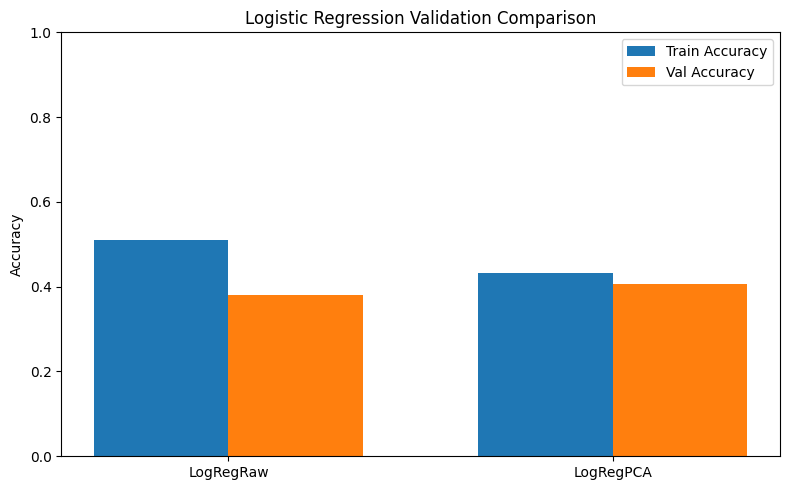

Saved comparison plot to: /Users/anishsajja/Documents/GitHub/CS178-goop-squad-CIFAR10/outputs/graphs/logreg_model_comparison.png
Best validation model: LogRegPCA
{
  "accuracy": 0.4065,
  "macro_precision": 0.40162863803092747,
  "macro_recall": 0.40650000000000003,
  "macro_f1": 0.4026708966991275,
  "per_class": {
    "airplane": {
      "precision": 0.4376130198915009,
      "recall": 0.484,
      "f1": 0.45963912630579296,
      "support": 1000
    },
    "automobile": {
      "precision": 0.4782178217821782,
      "recall": 0.483,
      "f1": 0.48059701492537316,
      "support": 1000
    },
    "bird": {
      "precision": 0.3,
      "recall": 0.264,
      "f1": 0.28085106382978725,
      "support": 1000
    },
    "cat": {
      "precision": 0.28861330326944756,
      "recall": 0.256,
      "f1": 0.2713301536830949,
      "support": 1000
    },
    "deer": {
      "precision": 0.3716475095785441,
      "recall": 0.291,
      "f1": 0.32641615255187884,
      "support": 1000
    }

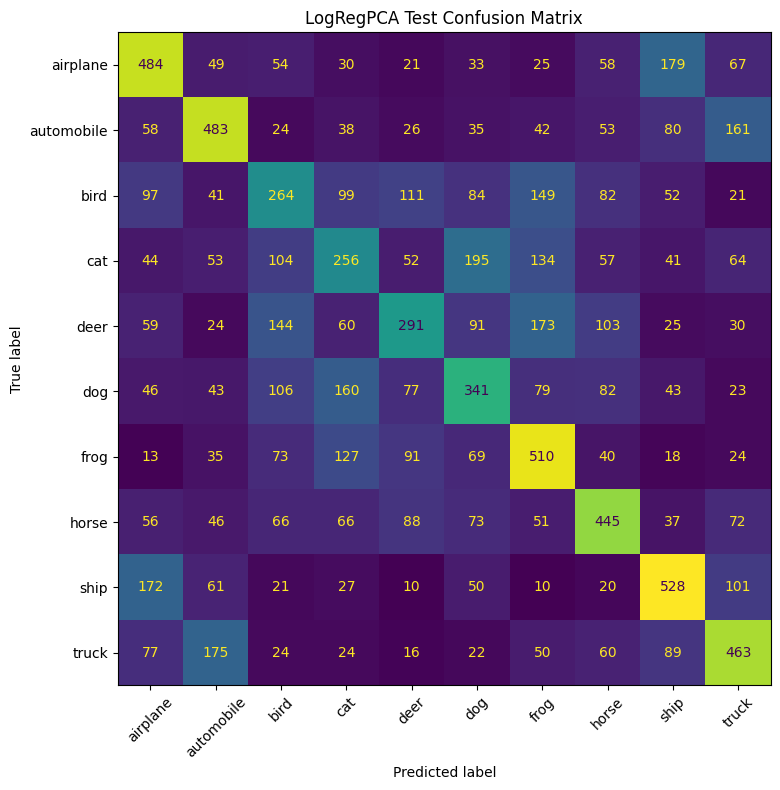

Saved confusion matrix to: /Users/anishsajja/Documents/GitHub/CS178-goop-squad-CIFAR10/outputs/graphs/logregpca_confusion_matrix.png


In [11]:
comparison_plot_path = plot_model_comparison(comparison_rows)
print("Saved comparison plot to:", comparison_plot_path)

best_row = comparison_df.iloc[0]
best_weights_path = WEIGHTS_DIR / f"{best_row['model_label'].lower()}_best.pkl"
test_result = evaluate_saved_model(best_weights_path)

print("Best validation model:", best_row["model_label"])
print(json.dumps(test_result["metrics"], indent=2))

cm_path = plot_confusion(
    test_result["confusion_matrix"],
    class_names,
    f"{best_row['model_label']} Test Confusion Matrix",
    best_row["model_label"].lower(),
)
print("Saved confusion matrix to:", cm_path)